In [61]:
# cell 1
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from PIL import Image
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print('All imports OK')

All imports OK


In [62]:
# cell 2
PROJECT_ROOT   = Path('..')
DATA_RAW       = PROJECT_ROOT / 'data' / 'raw'

# Correct paths — one extra nesting level in each dataset
DEFECT_ROOT    = DATA_RAW / 'defect-collection' / 'Defect Identification System' / 'Defect Identification System'
CORROSION_ROOT = DATA_RAW / 'corrosion-detect'
COLOR_ROOT     = DATA_RAW / 'color-classification' / 'ColorClassification' / 'ColorClassification'

for p in [DEFECT_ROOT, CORROSION_ROOT, COLOR_ROOT]:
    status = '✅' if p.exists() else '❌'
    print(f'{status}  {p.name}')

✅  Defect Identification System
✅  corrosion-detect
✅  ColorClassification


In [63]:
# cell 3
def collect_image_records(root: Path, dataset_name: str) -> list[dict]:
    '''Walk a folder tree and collect one record per image file.'''
    records = []
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
    for img_path in sorted(root.rglob('*')):
        if img_path.suffix.lower() in image_exts:
            records.append({
                'dataset': dataset_name,
                'class':   img_path.parent.name,
                'group':   img_path.parent.parent.name,
                'path':    img_path,
                'size_kb': round(img_path.stat().st_size / 1024, 2),
            })
    return records

defect_records = collect_image_records(DEFECT_ROOT, 'defect-collection')
df_defect = pd.DataFrame(defect_records)
print(f'Total images found: {len(df_defect)}')
print()
print(df_defect.groupby(['group', 'class']).size().to_string())

Total images found: 120

group                    class               
Machinery_Defect_Images  Corrosion               8
                         Defective Component     6
                         Faulty Wiring           6
                         Fracture and Cracks     6
                         Lubrication Failures    6
                         Overheating             6
Paint_Defect_Images      Adhesion Loss           6
                         Blistering              7
                         Chalking                6
                         Crack                   6
                         Fading                  6
                         Sagging                 6
Weld_Defect_Images       Bad Weld                4
                         Burnthrough Weld        6
                         Crack                   6
                         Misalignment Weld       5
                         Perfect Weld            6
                         Porous Weld             6
           

In [64]:
# cell 4
corrosion_imgs = sorted((CORROSION_ROOT / 'corrosion detect' / 'images').rglob('*.jpeg')) + \
                 sorted((CORROSION_ROOT / 'corrosion detect' / 'images').rglob('*.jpg'))  + \
                 sorted((CORROSION_ROOT / 'corrosion detect' / 'images').rglob('*.png'))

corrosion_lbls = sorted((CORROSION_ROOT / 'corrosion detect' / 'labels').rglob('*.txt'))

print(f'Corrosion images : {len(corrosion_imgs)}')
print(f'Corrosion labels : {len(corrosion_lbls)}')

# Show sample label to confirm YOLO format
sample_lbl = corrosion_lbls[0]
print(f'\nSample label — {sample_lbl.name}:')
print(sample_lbl.read_text()[:200])

Corrosion images : 268
Corrosion labels : 268

Sample label — image1.txt:
1 0.863963 0.356554 0.190114 0.101284
1 0.275349 0.644476 0.309886 0.0970043
1 0.203739 0.546679 0.153992 0.0599144
1 0.359104 0.485497 0.152091 0.0485021
1 0.513836 0.490728 0.123574 0.0684736
1 0.39


In [65]:
# cell 5
# Canonical color classes (ignore mask_ and testimg folders for now)
COLOR_CLASSES = ['Black', 'Blue', 'Brown', 'Green', 'orange', 'red', 'Violet', 'White', 'yellow']

color_records = []
for cls in COLOR_CLASSES:
    folder = COLOR_ROOT / cls
    if folder.exists():
        for img_path in sorted(folder.iterdir()):
            if img_path.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
                color_records.append({
                    'dataset': 'color-classification',
                    'class':   cls.lower(),
                    'path':    img_path,
                    'size_kb': round(img_path.stat().st_size / 1024, 2),
                })

df_color = pd.DataFrame(color_records)
print(f'Total color images: {len(df_color)}')
print()
print(df_color.groupby('class').size().sort_values(ascending=False).to_string())

Total color images: 117

class
brown     20
violet    20
white     17
red       12
black     11
blue      10
orange    10
yellow    10
green      7


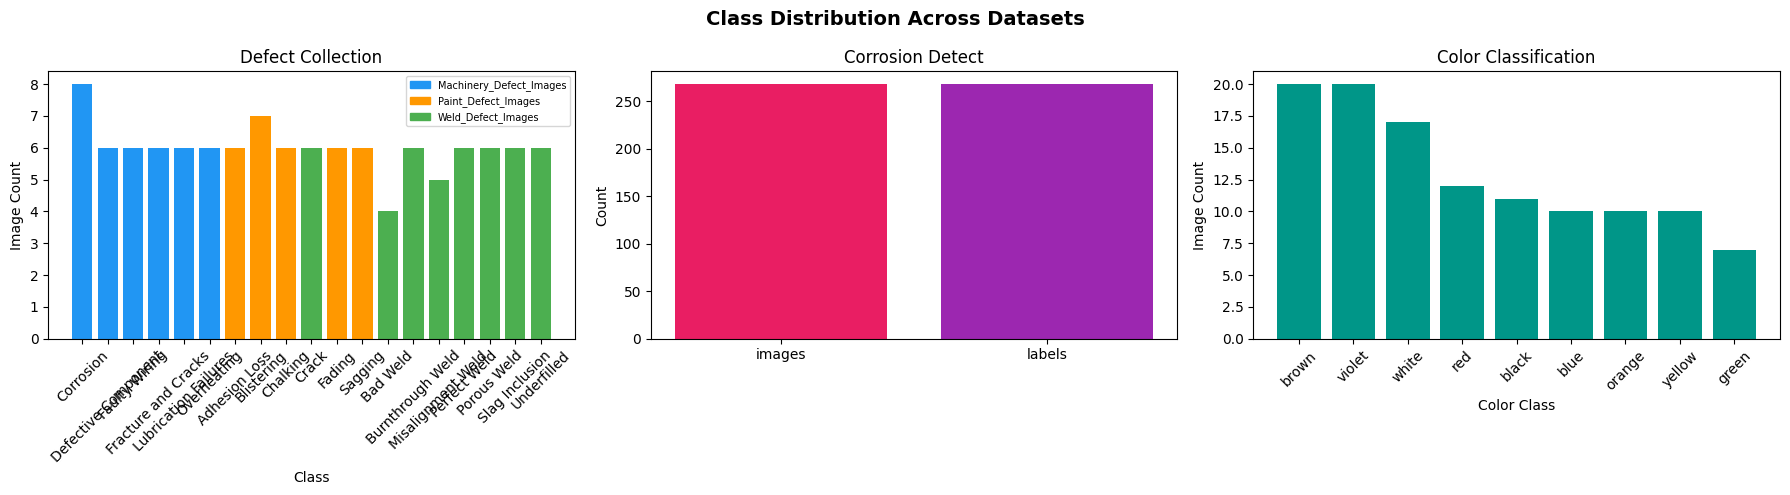

Saved → reports/class_distribution.png


In [54]:
# cell 6
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Class Distribution Across Datasets', fontsize=14, fontweight='bold')

# --- Defect collection (paint + weld + machinery) ---
defect_counts = df_defect.groupby(['group', 'class']).size().reset_index(name='count')
groups = defect_counts['group'].unique()
colors_map = {g: c for g, c in zip(groups, ['#2196F3', '#FF9800', '#4CAF50'])}
bars = axes[0].bar(
    defect_counts['class'],
    defect_counts['count'],
    color=[colors_map[g] for g in defect_counts['group']]
)
axes[0].set_title('Defect Collection')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Image Count')
axes[0].tick_params(axis='x', rotation=45)
legend_patches = [mpatches.Patch(color=colors_map[g], label=g) for g in groups]
axes[0].legend(handles=legend_patches, fontsize=7)

# --- Corrosion (single class, show image vs label count) ---
axes[1].bar(['images', 'labels'], [len(corrosion_imgs), len(corrosion_lbls)], color=['#E91E63', '#9C27B0'])
axes[1].set_title('Corrosion Detect')
axes[1].set_ylabel('Count')

# --- Color classification ---
color_counts = df_color.groupby('class').size().sort_values(ascending=False)
axes[2].bar(color_counts.index, color_counts.values, color='#009688')
axes[2].set_title('Color Classification')
axes[2].set_xlabel('Color Class')
axes[2].set_ylabel('Image Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/class_distribution.png')

Width  — min:  147  max: 1300  mean: 438
Height — min:  128  max:  956  mean: 327


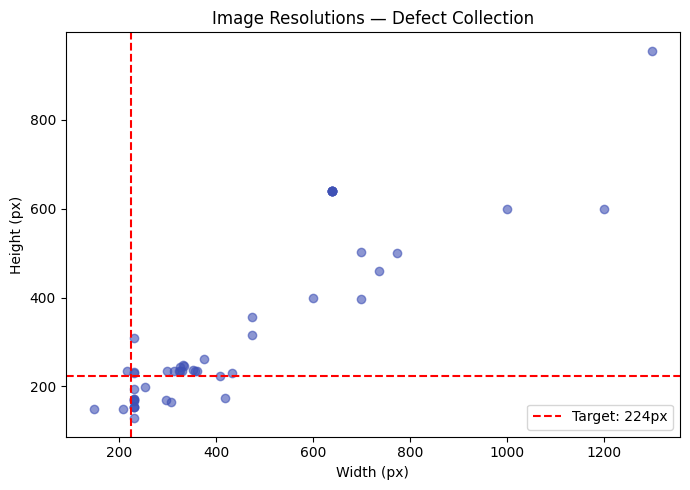

In [33]:
# cell 7
def get_image_dims(path: Path) -> tuple[int, int]:
    try:
        with Image.open(path) as img:
            return img.size  # (width, height)
    except Exception:
        return (0, 0)

# Sample up to 50 images from defect collection for speed
sample_paths = df_defect['path'].sample(min(50, len(df_defect)), random_state=42).tolist()
dims = [get_image_dims(p) for p in sample_paths]
widths  = [d[0] for d in dims if d[0] > 0]
heights = [d[1] for d in dims if d[1] > 0]

print(f'Width  — min: {min(widths):4d}  max: {max(widths):4d}  mean: {np.mean(widths):.0f}')
print(f'Height — min: {min(heights):4d}  max: {max(heights):4d}  mean: {np.mean(heights):.0f}')

# Scatter plot of resolutions
plt.figure(figsize=(7, 5))
plt.scatter(widths, heights, alpha=0.6, color='#3F51B5')
plt.axvline(224, color='red', linestyle='--', label='Target: 224px')
plt.axhline(224, color='red', linestyle='--')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
plt.title('Image Resolutions — Defect Collection')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/resolution_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

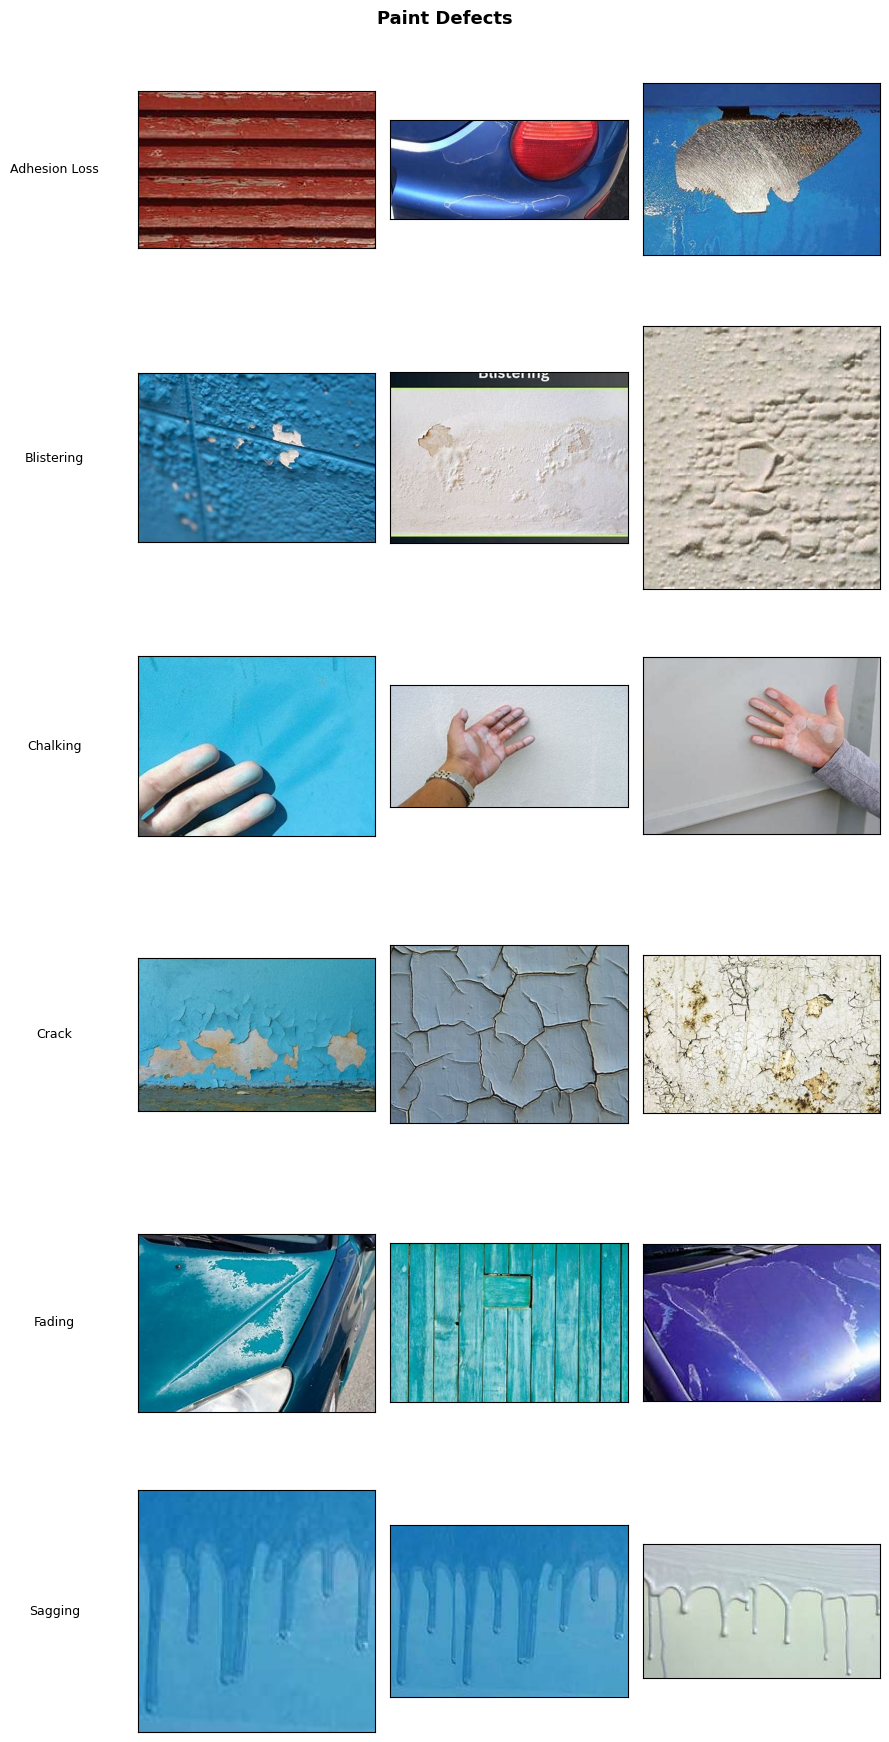

In [34]:
# cell 8
def show_sample_grid(records: list[dict], title: str, n_per_class: int = 3):
    classes = list({r['class'] for r in records})
    classes = sorted(classes)
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class * 3, len(classes) * 3))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for row, cls in enumerate(classes):
        cls_imgs = [r['path'] for r in records if r['class'] == cls][:n_per_class]
        for col in range(n_per_class):
            ax = axes[row, col] if len(classes) > 1 else axes[col]
            if col < len(cls_imgs):
                img = cv2.imread(str(cls_imgs[col]))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
            else:
                ax.axis('off')
            if col == 0:
                ax.set_ylabel(cls, fontsize=9, rotation=0, labelpad=60, va='center')
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(f'../reports/sample_grid_{title.replace(" ", "_").lower()}.png', dpi=120, bbox_inches='tight')
    plt.show()

# Show paint defects only first
paint_records = [r for r in defect_records if 'Paint' in r['group']]
show_sample_grid(paint_records, 'Paint Defects')

In [66]:
# cell 9
# Define our 7-class coatings scope
COATINGS_CLASSES = {
    'Adhesion Loss': 'adhesion_loss',
    'Blistering':    'blistering',
    'Chalking':      'chalking',
    'Crack':         'crack_paint',   # renamed to avoid collision
    'Fading':        'fading',
    'Sagging':       'sagging',
    'Corrosion':     'corrosion',
}

# Filter records to only coatings-relevant classes
# Use group filter to grab Paint Defects + Corrosion only
coatings_records = [
    r for r in defect_records
    if (r['group'] == 'Paint_Defect_Images') or
       (r['group'] == 'Machinery_Defect_Images' and r['class'] == 'Corrosion')
]

# Apply canonical label names
for r in coatings_records:
    r['label'] = COATINGS_CLASSES[r['class']]

df_coatings = pd.DataFrame(coatings_records)

print('Coatings dataset scope:')
print(df_coatings.groupby('label').size().sort_values(ascending=False).to_string())
print(f'\nTotal images in scope: {len(df_coatings)}')
print(f'Number of classes    : {df_coatings["label"].nunique()}')

Coatings dataset scope:
label
corrosion        8
blistering       7
adhesion_loss    6
chalking         6
crack_paint      6
fading           6
sagging          6

Total images in scope: 45
Number of classes    : 7


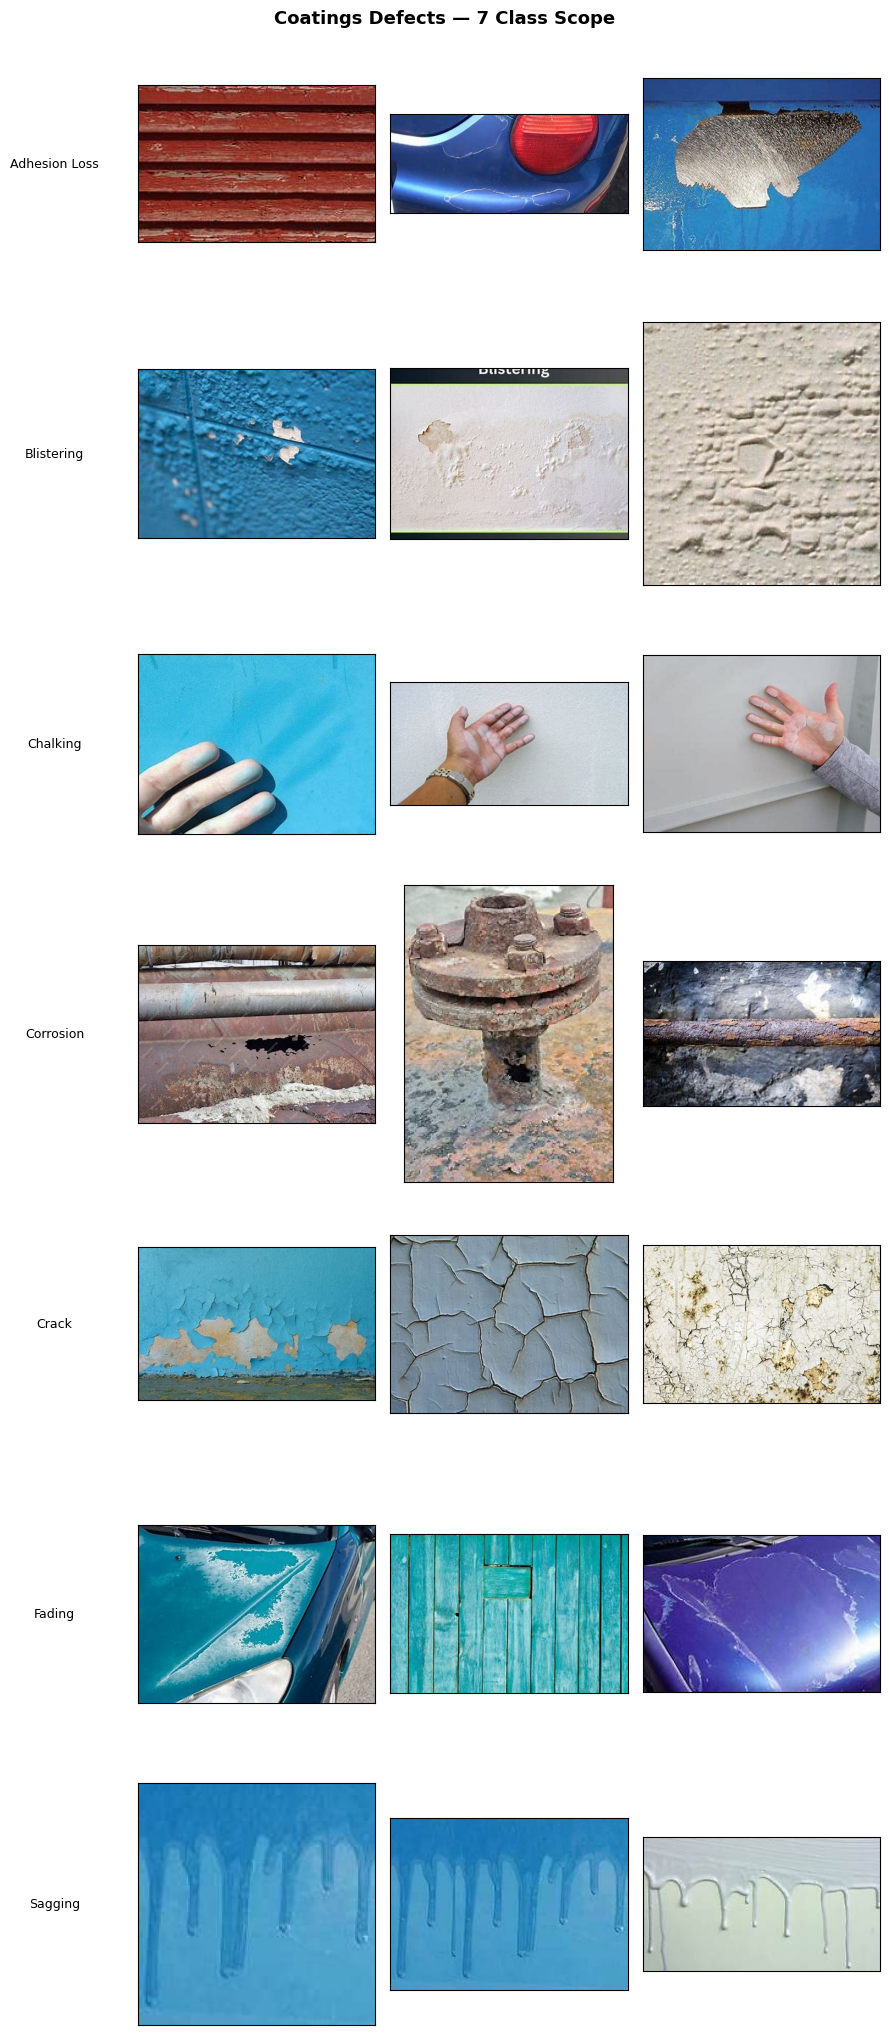

In [67]:
# cell 10
show_sample_grid(coatings_records, 'Coatings Defects — 7 Class Scope', n_per_class=3)

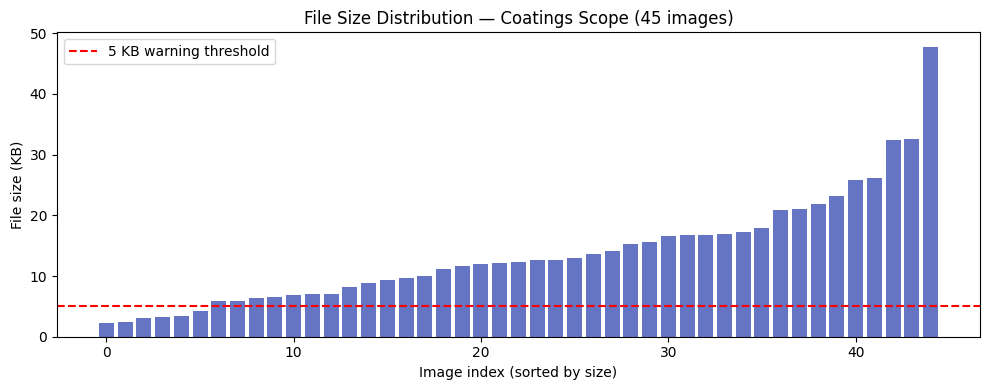

⚠️  6 images smaller than 5KB — inspect these:
       label                                                                                                                                  path  size_kb
26  chalking  ..\data\raw\defect-collection\Defect Identification System\Defect Identification System\Paint_Defect_Images\Chalking\Chalking_06.jpg     4.26
39   sagging    ..\data\raw\defect-collection\Defect Identification System\Defect Identification System\Paint_Defect_Images\Sagging\Sagging_01.jpg     2.24
40   sagging    ..\data\raw\defect-collection\Defect Identification System\Defect Identification System\Paint_Defect_Images\Sagging\Sagging_02.jpg     3.38
41   sagging    ..\data\raw\defect-collection\Defect Identification System\Defect Identification System\Paint_Defect_Images\Sagging\Sagging_03.jpg     3.22
43   sagging    ..\data\raw\defect-collection\Defect Identification System\Defect Identification System\Paint_Defect_Images\Sagging\Sagging_05.jpg     2.49
44   sagging    .

In [23]:
# cell 11
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(range(len(df_coatings)), df_coatings.sort_values('size_kb')['size_kb'], color='#3F51B5', alpha=0.8)
ax.axhline(y=5, color='red', linestyle='--', label='5 KB warning threshold')
ax.set_xlabel('Image index (sorted by size)')
ax.set_ylabel('File size (KB)')
ax.set_title('File Size Distribution — Coatings Scope (45 images)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/filesize_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag suspiciously small files (likely corrupt or placeholder)
tiny = df_coatings[df_coatings['size_kb'] < 5]
if len(tiny) > 0:
    print(f'⚠️  {len(tiny)} images smaller than 5KB — inspect these:')
    print(tiny[['label', 'path', 'size_kb']].to_string())
else:
    print('✅ No suspiciously small images found.')

In [68]:
# cell 12
print('=' * 55)
print('EDA SUMMARY — COATINGS DEFECT DATASET')
print('=' * 55)
print(f'  Total images in scope  : {len(df_coatings)}')
print(f'  Number of classes      : {df_coatings["label"].nunique()}')
print(f'  Min images per class   : {df_coatings.groupby("label").size().min()}')
print(f'  Max images per class   : {df_coatings.groupby("label").size().max()}')
print(f'  Avg images per class   : {df_coatings.groupby("label").size().mean():.1f}')
print()
print('  KEY CONSTRAINTS:')
print('  - Too few to train from scratch → transfer learning required')
print('  - Too few to hold a proper test set → use k-fold cross validation')
print('  - Augmentation must be the primary data strategy')
print()
print('  NEXT STEPS:')
print('  1. Augmentation pipeline design (Albumentations)')
print('  2. Transfer learning with frozen backbone (EfficientNet-S)')
print('  3. 5-fold stratified cross validation instead of single split')
print('  4. Save df_coatings as the canonical manifest for all future steps')
print('=' * 55)

EDA SUMMARY — COATINGS DEFECT DATASET
  Total images in scope  : 45
  Number of classes      : 7
  Min images per class   : 6
  Max images per class   : 8
  Avg images per class   : 6.4

  KEY CONSTRAINTS:
  - Too few to train from scratch → transfer learning required
  - Too few to hold a proper test set → use k-fold cross validation
  - Augmentation must be the primary data strategy

  NEXT STEPS:
  1. Augmentation pipeline design (Albumentations)
  2. Transfer learning with frozen backbone (EfficientNet-S)
  3. 5-fold stratified cross validation instead of single split
  4. Save df_coatings as the canonical manifest for all future steps


In [71]:
# cell 13
# Save CSV manifest — paths stored as strings relative to project root
manifest_path = PROJECT_ROOT / 'data' / 'coatings_manifest.csv'

df_save = df_coatings[['label', 'group', 'size_kb']].copy()
df_save['path'] = df_coatings['path'].apply(
    lambda p: p.resolve().relative_to(PROJECT_ROOT.resolve()).as_posix()
)

df_save.to_csv(manifest_path, index=False)
print(f'Manifest saved -> {manifest_path}')
print(f'Shape: {df_save.shape}')
print()
print(df_save.head(3).to_string())

Manifest saved -> ..\data\coatings_manifest.csv
Shape: (45, 4)

       label                    group  size_kb                                                                                                                                            path
0  corrosion  Machinery_Defect_Images    23.18  data/raw/defect-collection/Defect Identification System/Defect Identification System/Machinery_Defect_Images/Corrosion/corrosion_defect_01.jpg
1  corrosion  Machinery_Defect_Images    14.19  data/raw/defect-collection/Defect Identification System/Defect Identification System/Machinery_Defect_Images/Corrosion/corrosion_defect_02.jpg
2  corrosion  Machinery_Defect_Images    25.76  data/raw/defect-collection/Defect Identification System/Defect Identification System/Machinery_Defect_Images/Corrosion/corrosion_defect_03.jpg
